## 🫀 Problem Statement
Heart disease is a leading cause of death globally. This project uses the 
Heart Disease UCI Dataset to predict whether a patient is at risk using 
clinical features like age, cholesterol, and chest pain type.

Goal: Binary classification → 0 = Healthy, 1 = At Risk  
Models: Logistic Regression & Decision Tree  
Metrics: Accuracy, Confusion Matrix, ROC-AUC

##### 1. Import Libraries 

In [ ]:
import pandas as pd #dataframe 
import sklearn as sk #for models import and training and testing
import matplotlib.pyplot as plt #create graphs
import seaborn as sns #visualization 
from sklearn.model_selection import train_test_split #split the data into training and testing parts
from sklearn.preprocessing import StandardScaler #scale the features  on one level 
from sklearn.linear_model import LogisticRegression  #model1 
from sklearn.tree import DecisionTreeClassifier #model 2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #metrics that helps to check either model perform well or not 



##### 2. Load The Dataset Of HeartDiseases

In [149]:
data=pd.read_csv(r"C:\Users\Muteeba Ali\Downloads\Compressed\archive\heart_disease_uci.csv")
data

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


##### 3. Check Columns Name

In [150]:
data.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

##### 4. Check The Null Values And Structure Of Data 

In [151]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


##### 5. Check The Sum Of Null Values 

In [152]:
data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

##### 6. Outliers Detection

In [153]:
# 1. Sirf numerical columns ko select karein (id ko chor kar)
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = [col for col in numerical_cols if col != 'id']

print("--- Poore Dataset Ke Outliers Ka Count ---")

# 2. Loop ke zariye har column ka IQR nikalain
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Boundaries set 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Is column ke outliers nikalain (null values ko chor kar)
    outliers_count = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col].dropna().count()
    print(f"Column '{col}': Total Outliers = {outliers_count}")

--- Poore Dataset Ke Outliers Ka Count ---
Column 'age': Total Outliers = 0
Column 'trestbps': Total Outliers = 28
Column 'chol': Total Outliers = 183
Column 'thalch': Total Outliers = 2
Column 'oldpeak': Total Outliers = 16
Column 'ca': Total Outliers = 20
Column 'num': Total Outliers = 0


##### 7. check correlaton b/w numeric columns

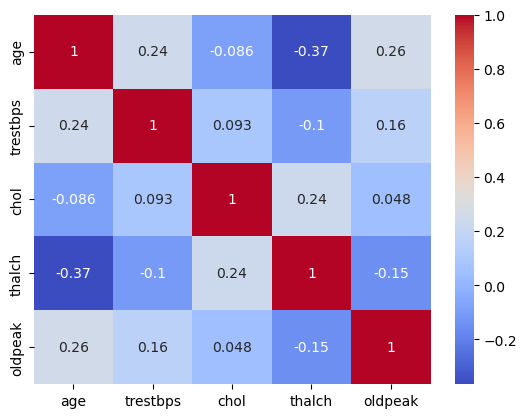

In [154]:
data[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].corr()

#Through graph check the correlation
sns.heatmap(data[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].corr(), annot=True, cmap='coolwarm')
plt.show()

##### 8. Drop 2 columns thats not necessary

In [155]:
data.drop(columns=['id','dataset'], inplace=True) #Remove the id and dataset column that is not important in heart diseases prediction

##### 9. Fill the values 

In [156]:
# Numerical cols: Outliers ki wajah se median use kiya
data['chol'] = data['chol'].fillna(data['chol'].median())
data['trestbps'] = data['trestbps'].fillna(data['trestbps'].median())
data['thalch'] = data['thalch'].fillna(data['thalch'].median())
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].median())

# Categorical cols: Groups hain, isliye sabsay zyada aane wali value (Mode) use ki
data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
data['restecg'] = data['restecg'].fillna(data['restecg'].mode()[0])
data['exang'] = data['exang'].fillna(data['exang'].mode()[0])

# Special col: 60% data missing tha, isliye new category '-1' de di
data['ca'] = data['ca'].fillna(-1)

C:\Users\Muteeba Ali\AppData\Local\Temp\ipykernel_15848\3275308834.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['fbs'] = data['fbs'].fillna(data['fbs'].mode()[0])
C:\Users\Muteeba Ali\AppData\Local\Temp\ipykernel_15848\3275308834.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['exang'] = data['exang'].fillna(data['exang'].mode()[0])


##### 10. Again Check NullValues After Filling

In [157]:
data.isnull().sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope       309
ca            0
thal        486
num           0
dtype: int64

##### 11. Use OneHotEncoding To convert the categorical values into 0 & 1

In [158]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal','sex'] 

# pd.get_dummies automatically string/object columns ko convert kar deta hai
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

data.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,sex_Male
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,0,0,1,0,0,0,0,0,0,1
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,0,0,0,0,0,1,0,1,0,1
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,0,0,0,0,0,1,0,0,1,1
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,0,1,0,1,0,0,0,1,0,1
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,1,0,0,0,0,0,1,1,0,0


##### 12. Target Variable Transformation (Multi-class to Binary)

In [159]:
# 1, 2, 3, 4 sab ko 1 se replace kar do, 0 ko chor do
data['num'] = data['num'].replace({2: 1, 3: 1, 4: 1})

# Tasalli ke liye unique values check karein
print(data['num'].unique())

[0 1]


### 📊 13. Key Demographic Trends
* **Gender vs Risk:** Checking the heart disease ratio between males and females.
* **Age vs Risk:** Comparing the average age of healthy individuals versus heart disease patients.

In [160]:
print("Heart Disease Ratio by Gender:")
print(data.groupby('sex_Male')['num'].mean())

print("\n Average Age by Target Class:")
print(data.groupby('num')['age'].mean())

Heart Disease Ratio by Gender:
sex_Male
0    0.257732
1    0.632231
Name: num, dtype: float64

 Average Age by Target Class:
num
0    50.547445
1    55.903733
Name: age, dtype: float64


##### 14. Feature And Target Variable



In [161]:
#Features (X) anf Target (y) 
X = data.drop(columns=['num'])
y = data['num']

##### 15. Split Into Training And Testing Parts

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Train-Test Split (80%  for Training and  20%  for Testing)

##### 16. Feature Scaling

In [163]:
# Feature Scaling (StandardScaler)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Training data ka mean/std nikal kar scale karna
X_test_scaled = scaler.transform(X_test)        # Test data ko usi training wale scale par badalna

##### 17. Model  Logistic Regression

In [164]:
model_LR = LogisticRegression() #create the model object
model_LR.fit(X_train_scaled, y_train) #now model trained on the scaled data 


LogisticRegression()

##### 18. Model_LR Prediction

In [165]:
y_pred = model_LR.predict(X_test_scaled) #model apply multiple prediction on the test data
y_pred

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1])

##### 19. Check Accuracy Of Model LR

In [166]:
accuracy = accuracy_score(y_test, y_pred) #check model accuracy
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 79.89%


##### 20. Model Decision Tree

In [167]:
model_DR=DecisionTreeClassifier()  #create the model object
model_DR.fit(X_train_scaled, y_train)  #now model trained on the scaled data 

DecisionTreeClassifier()

##### 21. Model DR Prediction & Check Score

In [168]:
y2_pred = model_DR.predict(X_test_scaled) #model apply multiple prediction on the test data
print(y2_pred,'\n')

accuracy_DR= accuracy_score(y_test, y2_pred) #check model accuracy
print(f"Model Decision_Tree Accuracy: {accuracy_DR * 100:.2f}%")


[0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0
 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 1
 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 1 1 1
 0 1 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1] 

Model Decision_Tree Accuracy: 76.09%


##### 22. Confusion_Matrix

In Easy Wording
Sahi aur Ghalat Predictions ka Shumar:
Sahi pehchane gaye Healthy log: 60
Ghalat pehchane gaye Healthy log (False Alarm): 15
Ghalat pehchane gaye Bimar log (Missed): 22
Sahi pehchane gaye Bimar log: 87


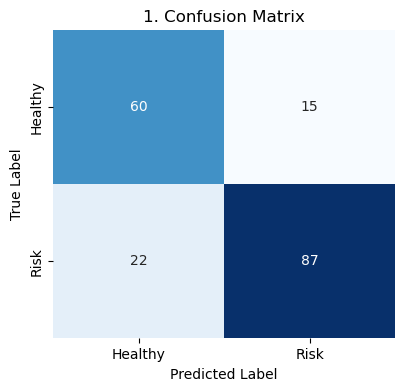

In [169]:
# Confusion matrix  (True vs Predicted)
cm = confusion_matrix(y_test, y_pred) 

#For Decision_tree 
#cm = confusion_matrix(y_test, y2_pred)  

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy', 'Risk'], yticklabels=['Healthy', 'Risk'])
plt.title('1. Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
  
print('In Easy Wording')

print("Sahi aur Ghalat Predictions ka Shumar:")
print(f"Sahi pehchane gaye Healthy log: {cm[0][0]}")
print(f"Ghalat pehchane gaye Healthy log (False Alarm): {cm[0][1]}")
print(f"Ghalat pehchane gaye Bimar log (Missed): {cm[1][0]}")
print(f"Sahi pehchane gaye Bimar log: {cm[1][1]}")


##### 23. Roc Score

In [170]:
#On  Test data calculate probabilities to check the score of AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Model ka ROC-AUC Score hai: {auc_score:.2f}")

Model ka ROC-AUC Score hai: 0.89


##### 24. ROC Graph 

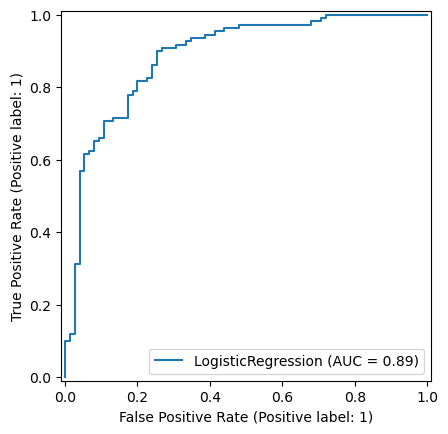

In [174]:
RocCurveDisplay.from_estimator(model_LR, X_test_scaled, y_test) #automaticall calculate probability and print the auc score

### 🔑 Main Reasons for Heart Disease (Feature Importance)

According to our Machine Learning model, here are the most important features that affect the prediction:

1. **🚨 Higher Risk (Bimari barhane wale):**
   * **`sex_Male`:** Male patients have a higher risk of heart disease in this dataset.
   * **`oldpeak`:** High ST depression values strongly indicate heart risk.

2. **🛡️ Lower Risk (Bimari kam karne wale):**
   * **`cp_atypical angina`:** Patients with atypical chest pain are mostly safe and less likely to have heart disease.